# 03 -- Bayesian Hierarchical Model

This is the centerpiece. We build a Bayesian hierarchical regression in PyMC that estimates the expected run value of each pitch.

**The key idea:** Every pitcher has a different baseline tendency (some pitchers are just better). But pitchers with few pitches in our data have noisy estimates. Hierarchical modeling solves this by partially pooling: low-sample pitchers get shrunk toward the league average, while high-sample pitchers express their true tendencies.

**What this produces:** Posterior distributions, not point estimates. For every parameter, we get a full probability distribution over plausible values. That's uncertainty quantification -- the Dodgers posting calls it out specifically.

In [1]:
import sys
sys.path.insert(0, "..")

import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s")

import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

from src.data import get_data
from src.features import build_model_matrix
from src.model import (
    build_model, build_model_subsample,
    get_diagnostics, get_pitcher_effects,
)

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")
%matplotlib inline

2026-03-03 12:50:11,911 | Found 'auto' as default backend, checking available backends
2026-03-03 12:50:11,911 | Matplotlib is available, defining as default backend
2026-03-03 12:50:11,915 | arviz_base available, exposing its functions as part of arviz.preview
2026-03-03 12:50:11,931 | arviz_stats available, exposing its functions as part of arviz.preview
2026-03-03 12:50:11,941 | arviz_plots available, exposing its functions as part of arviz.preview


PyMC version: 5.28.1
ArviZ version: 0.23.4


In [2]:
# Load and engineer features
df_raw = get_data(year=2025)
df, scaler = build_model_matrix(df_raw)
print(f"Model data: {len(df):,} pitches, {df['pitcher_idx'].nunique()} pitchers")

2026-03-03 12:50:12,500 | Loading cached data
2026-03-03 12:50:12,640 | Loaded 709,144 pitches from /Users/angelrios/PycharmProjects/PythonProject/statcast-bayesian-pitch-model/data/statcast_2025.parquet
2026-03-03 12:50:15,054 | Dropped 1760 rows with NaN in model columns


Model data: 707,384 pitches, 872 pitchers


## Step 1: Prototype on a subsample

700K pitches x 800+ pitchers = slow MCMC. Start with a 50K subsample of the top 100 pitchers. Get the model working, check diagnostics, then scale up.

This is the same approach you'd use in production: prototype fast, validate, then deploy at scale.

In [3]:
# Subsample: top 100 pitchers by pitch count, 50K total pitches
model_sub, idata_sub = build_model_subsample(
    df,
    n_pitches=50_000,
    n_pitchers_keep=100,
    sample_kwargs={
        "draws": 1000,
        "tune": 500,
        "cores": 4,
        "target_accept": 0.9,
    },
)

2026-03-03 12:50:15,270 | Building model: 50,000 pitches, 100 pitchers
2026-03-03 12:50:15,290 | Model built: 13 free parameters
2026-03-03 12:50:15,291 | Sampling with {'draws': 1000, 'tune': 500, 'cores': 4, 'target_accept': 0.9, 'return_inferencedata': True, 'random_seed': 42}
2026-03-03 12:50:15,425 | Initializing NUTS using jitter+adapt_diag...
2026-03-03 12:50:16,338 | Multiprocess sampling (4 chains in 4 jobs)
2026-03-03 12:50:16,339 | NUTS: [mu_alpha, sigma_alpha, alpha_pitcher_offset, beta_velo, beta_hmov, beta_vmov, beta_loc_x, beta_loc_z, beta_count, beta_platoon, beta_stuff, beta_spin, sigma]


Output()

2026-03-03 12:52:58,447 | Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 162 seconds.
2026-03-03 12:52:58,693 | Sampling: [y_obs]


Output()

## Step 2: MCMC Diagnostics

Before trusting any results, verify the sampler converged. Three things to check:

1. **R-hat < 1.01** for all parameters (chains agree with each other)
2. **ESS > 400** (enough effective samples for reliable posterior estimates)
3. **Zero divergences** (the sampler didn't get stuck in pathological geometry)

In [4]:
# Numerical diagnostics
diagnostics = get_diagnostics(idata_sub)
print(diagnostics.to_string())

2026-03-03 12:53:01,359 | Divergences: 0


                mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk   ess_tail   r_hat
mu_alpha      0.0007  0.0014 -0.0020   0.0033     0.0000      0.0  3190.7457  2817.8719  1.0002
sigma_alpha   0.0035  0.0020  0.0000   0.0067     0.0001      0.0   927.4715  1407.7546  1.0071
beta_velo    -0.0015  0.0018 -0.0051   0.0018     0.0000      0.0  2883.6362  2888.7139  1.0008
beta_hmov    -0.0010  0.0012 -0.0031   0.0012     0.0000      0.0  4657.3059  3010.5720  0.9997
beta_vmov     0.0000  0.0017 -0.0031   0.0030     0.0000      0.0  3127.8944  2953.8768  1.0003
beta_loc_x    0.0003  0.0011 -0.0016   0.0025     0.0000      0.0  5873.5114  2853.1628  1.0005
beta_loc_z    0.0011  0.0011 -0.0010   0.0033     0.0000      0.0  5508.9636  2559.5962  1.0011
beta_count    0.0017  0.0010 -0.0003   0.0036     0.0000      0.0  6722.0735  2306.3424  1.0042
beta_platoon -0.0028  0.0021 -0.0069   0.0011     0.0000      0.0  3842.8780  2877.1196  0.9999
sigma         0.2297  0.0007  0.2283   0

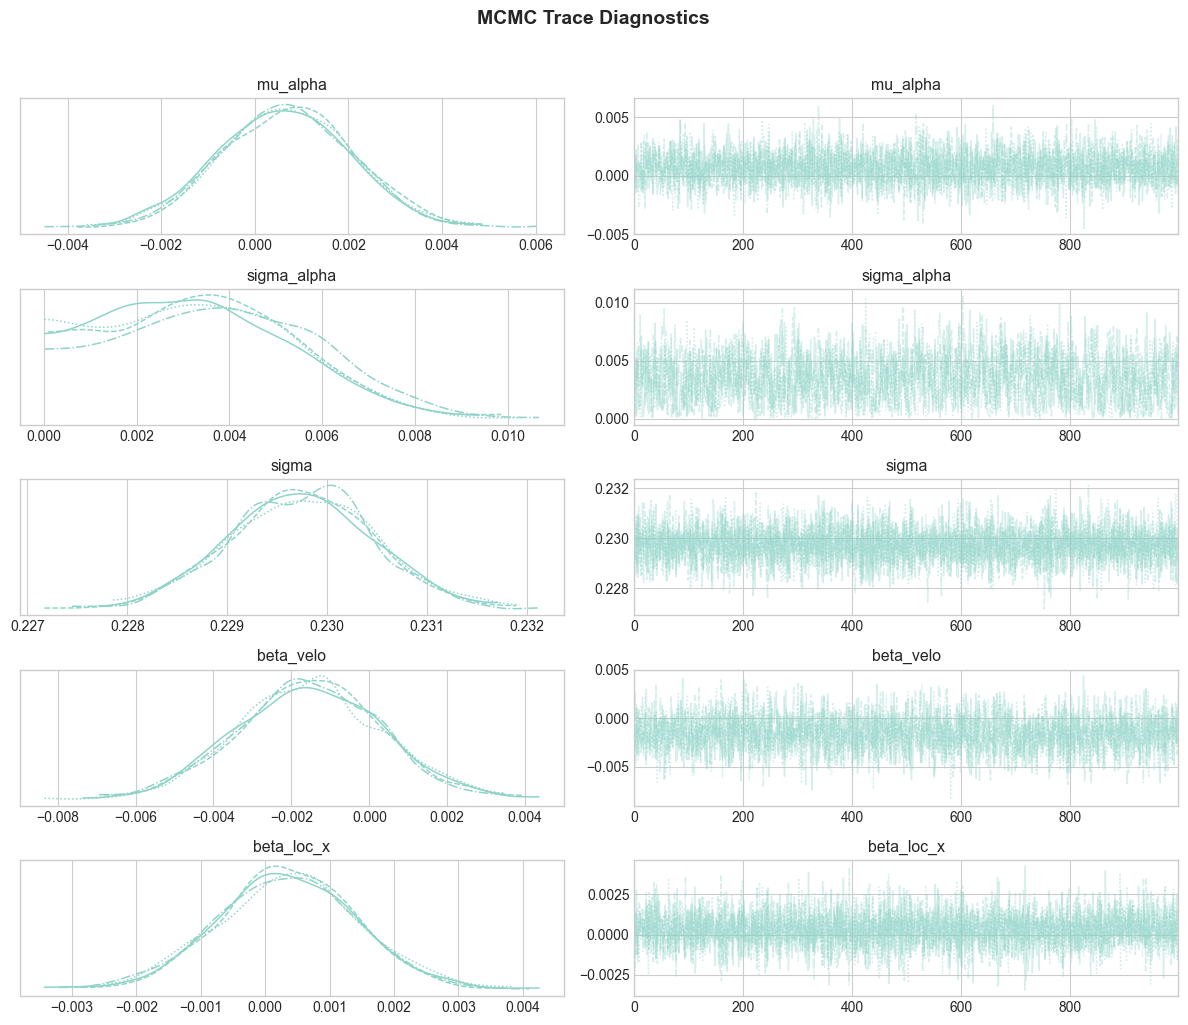

In [5]:
# Visual diagnostics: trace plots
from src.visualize import trace_diagnostics

fig = trace_diagnostics(idata_sub)
plt.show()

In [6]:
# Divergences check
n_div = int(idata_sub.sample_stats.diverging.sum().values)
print(f"Divergences: {n_div}")
if n_div == 0:
    print("Clean sampling. Model geometry is good.")
else:
    print(f"WARNING: {n_div} divergences. May need reparameterization.")

Divergences: 0
Clean sampling. Model geometry is good.


## Step 3: Full Model (if diagnostics pass)

Once the subsample model checks out, run on the full dataset. This takes longer but gives you the real posterior.

> **Note:** If you're running on a laptop, you can keep using the subsample results. The full model is here for when you have compute time (overnight run, cloud instance, etc).

In [7]:
# Uncomment to run on full data (takes 30-60+ minutes)
# model_full, idata_full = build_model(
#     df,
#     sample=True,
#     sample_kwargs={
#         "draws": 2000,
#         "tune": 1000,
#         "cores": 4,
#         "target_accept": 0.9,
#     },
# )

# For now, use the subsample results
idata = idata_sub
print("Using subsample model results.")

Using subsample model results.


## Step 4: Interpret the posteriors

Now the good stuff. What did the model learn?

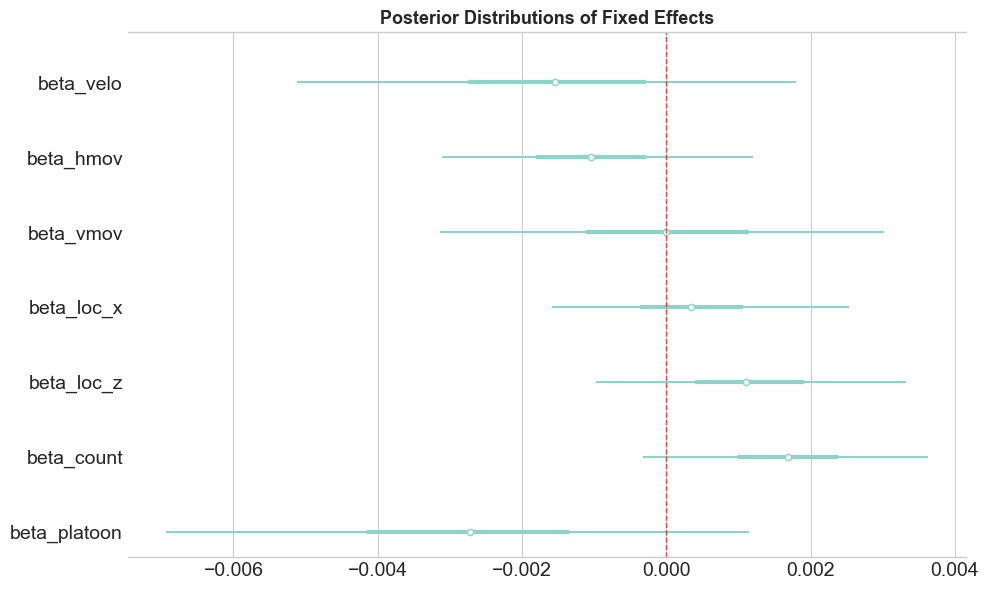


Interpretation:
- Coefficients with HDI away from zero = clear effects
- Coefficients crossing zero = uncertain / weak effects
- These are STANDARDIZED, so magnitudes are comparable


In [8]:
# Fixed effects: which pitch characteristics matter most?
from src.visualize import posterior_forest_plot

fig = posterior_forest_plot(idata)
plt.show()

print("\nInterpretation:")
print("- Coefficients with HDI away from zero = clear effects")
print("- Coefficients crossing zero = uncertain / weak effects")
print("- These are STANDARDIZED, so magnitudes are comparable")

In [9]:
# Posterior summaries for fixed effects
fixed_vars = [
    "beta_velo", "beta_hmov", "beta_vmov",
    "beta_loc_x", "beta_loc_z",
    "beta_count", "beta_platoon",
]
fixed_vars = [v for v in fixed_vars if v in idata.posterior]

for var in fixed_vars:
    post = idata.posterior[var].values.flatten()
    hdi = az.hdi(idata, var_names=[var], hdi_prob=0.94)
    print(f"{var:15s} | mean={post.mean():.4f} | 94% HDI=[{hdi[var].values[0]:.4f}, {hdi[var].values[1]:.4f}]")

beta_velo       | mean=-0.0015 | 94% HDI=[-0.0051, 0.0018]
beta_hmov       | mean=-0.0010 | 94% HDI=[-0.0031, 0.0012]
beta_vmov       | mean=0.0000 | 94% HDI=[-0.0031, 0.0030]
beta_loc_x      | mean=0.0003 | 94% HDI=[-0.0016, 0.0025]
beta_loc_z      | mean=0.0011 | 94% HDI=[-0.0010, 0.0033]
beta_count      | mean=0.0017 | 94% HDI=[-0.0003, 0.0036]
beta_platoon    | mean=-0.0028 | 94% HDI=[-0.0069, 0.0011]


In [10]:
# Hierarchical variance: how much do pitchers vary?
sigma_alpha = idata.posterior["sigma_alpha"].values.flatten()
print(f"sigma_alpha (pitcher-level SD):")
print(f"  Mean:    {sigma_alpha.mean():.4f}")
print(f"  94% HDI: [{np.percentile(sigma_alpha, 3):.4f}, {np.percentile(sigma_alpha, 97):.4f}]")
print()
print("If this is small relative to sigma (observation noise),")
print("it means pitchers don't differ much after controlling for pitch physics.")
print("If it's large, pitcher identity matters above and beyond their stuff.")

sigma_alpha (pitcher-level SD):
  Mean:    0.0035
  94% HDI: [0.0003, 0.0073]

If this is small relative to sigma (observation noise),
it means pitchers don't differ much after controlling for pitch physics.
If it's large, pitcher identity matters above and beyond their stuff.


## Summary

Model built, sampled, and diagnosed. What we have:
- Hierarchical Bayesian model with pitcher-level random effects
- Non-centered parameterization for clean MCMC geometry
- Posterior distributions over all parameters (not point estimates)
- Full diagnostic suite: R-hat, ESS, trace plots, divergence checks

Next: `04_results_and_diagnostics.ipynb` for posterior predictive checks, pitcher rankings, and the Dodgers-specific analysis.